# 01 — Ridge & Lasso with Adstock + Saturation

Linear model with:
- **Adstock** (geometric decay, computed *within* each division — see `mmm.data.apply_adstock_grouped`)
- **Hill saturation** (diminishing returns), gamma calibrated from **training weeks only**
- **Division fixed effects** (26 dummies) to absorb the ~20x between-division scale gap
- **log1p(organic_views, paid_views)** as controls (raw values are extremely skewed; log-transforming them was the single biggest fix to holdout performance — see the ablation below)
- **Month dummies** for seasonality (a single sin/cos(52) Fourier term was tried first and performed worse — it's too smooth for the sharp Nov/Dec spike documented in notebook 00)
- **log1p(sales)** as the regression target (raw sales has skew ≈ 5.6; log1p brings it to ≈ 0.66)

Adstock decay (θ), saturation gamma-fraction, and the ridge/lasso penalty are all selected by **walk-forward cross-validation within the training period only** (`mmm.eval.walk_forward_folds`) — the true 10-week holdout is touched exactly once, at the end, to report final numbers.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LassoCV
from sklearn.preprocessing import StandardScaler
from mmm import data as D
from mmm.eval import metrics, walk_forward_folds

df = D.load_panel()
train_weeks, test_weeks = D.time_split_weeks(df)
tr_mask = df["calendar_week"].isin(train_weeks)
te_mask = df["calendar_week"].isin(test_weeks)

month_dum = D.month_dummies(df)
div_dum = D.division_dummies(df)
logc = D.log_controls(df)
y_log = np.log1p(df[D.TARGET])


## Ablation: why log-controls + month dummies (not raw controls + smooth seasonality)

In [2]:
def make_X(media_feat, controls, season):
    return pd.concat([media_feat, controls, season, div_dum], axis=1)

def fit_holdout(X, scale_cols, alpha=0.1):
    X = X.copy()
    if scale_cols:
        sc = StandardScaler()
        X.loc[tr_mask, scale_cols] = sc.fit_transform(X.loc[tr_mask, scale_cols])
        X.loc[te_mask, scale_cols] = sc.transform(X.loc[te_mask, scale_cols])
    m = Ridge(alpha=alpha)
    m.fit(X.loc[tr_mask], y_log.loc[tr_mask])
    pred = np.expm1(m.predict(X.loc[te_mask]))
    return metrics(df.loc[te_mask, D.TARGET], pred)

media_feat = D.build_transformed_features(df, theta=0.5, gamma_frac=0.25, train_weeks=train_weeks)
season_smooth = D.add_seasonality(df)[["sin_52", "cos_52"]]
raw_controls = df[D.CONTROL_VARS]

ablation = {
    "div FE only":                       fit_holdout(pd.concat([div_dum], axis=1), []),
    "+ raw controls":                    fit_holdout(pd.concat([div_dum, raw_controls], axis=1), D.CONTROL_VARS),
    "+ log controls":                    fit_holdout(pd.concat([div_dum, logc], axis=1), list(logc.columns)),
    "+ media, smooth season, raw ctrl":  fit_holdout(make_X(media_feat, raw_controls, season_smooth), D.CONTROL_VARS + ["sin_52", "cos_52"]),
    "+ media, month dummies, log ctrl":  fit_holdout(make_X(media_feat, logc, month_dum := D.month_dummies(df)), list(logc.columns)),
}
pd.DataFrame(ablation).T


C:\Users\Georges Ghosn\AppData\Local\Temp\ipykernel_15600\2222866447.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.49031323 -0.46856797 -0.46559041 ...  0.13768257  0.2419425
  0.14562274]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[tr_mask, scale_cols] = sc.fit_transform(X.loc[tr_mask, scale_cols])
C:\Users\Georges Ghosn\AppData\Local\Temp\ipykernel_15600\2222866447.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.43662586 -0.42339381 -0.44704401 ... -0.13681102 -0.13215468
 -0.1934576 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[tr_mask, scale_cols] = sc.fit_transform(X.loc[tr_mask, scale_cols])
C:\Users\Georges Ghosn\AppData\Local\Temp\ipykernel_15600\2222866447.py:8: FutureWarning: Setting an item o

,R2,RMSE,MAPE
div FE only,0.874049,59860.978122,0.191499
+ raw controls,0.798101,75789.693467,0.202611
+ log controls,0.865205,61927.017150,0.229888
"+ media, smooth season, raw ctrl",0.747677,84726.962788,0.306199
"+ media, month dummies, log ctrl",0.831060,69328.019041,0.241485


The naive baseline from notebook 00 gets **R²≈0.885** on this holdout by knowing division identity alone. Every row above it in this ablation is worse than that — which is itself a finding, not a bug (see notebook 05). Adding log-controls and month dummies on top of media features recovers most of the gap versus using raw controls / smooth seasonality, which is why that combination is used for the tuned model below.

## Walk-forward CV: tune adstock θ, saturation γ, and the ridge/lasso penalty

In [3]:
folds = walk_forward_folds(train_weeks, n_folds=3, min_train_weeks=60, val_weeks=10)
print(f"{len(folds)} walk-forward folds (all strictly inside the 103 training weeks)")

def fit_eval_ridge(theta, gamma_frac, alpha, tr_w, va_w):
    feat = D.build_transformed_features(df, theta, gamma_frac, tr_w)
    X = pd.concat([feat, logc, month_dum, div_dum], axis=1)
    trm, vam = df["calendar_week"].isin(tr_w), df["calendar_week"].isin(va_w)
    sc = StandardScaler()
    Xtr, Xva = X.loc[trm].copy(), X.loc[vam].copy()
    cols = list(logc.columns)
    Xtr[cols] = sc.fit_transform(Xtr[cols]); Xva[cols] = sc.transform(Xva[cols])
    m = Ridge(alpha=alpha); m.fit(Xtr, y_log.loc[trm])
    pred = np.expm1(m.predict(Xva))
    return metrics(df.loc[vam, D.TARGET], pred)["R2"]

results = []
for theta in [0.1, 0.3, 0.5, 0.7]:
    for gamma_frac in [0.25, 0.5, 0.75]:
        for alpha in [0.1, 1.0, 10.0, 50.0]:
            r2s = [fit_eval_ridge(theta, gamma_frac, alpha, tw, vw) for tw, vw in folds]
            results.append({"theta": theta, "gamma_frac": gamma_frac, "alpha": alpha, "cv_r2": np.mean(r2s)})

res_df = pd.DataFrame(results).sort_values("cv_r2", ascending=False)
res_df.head(10)


3 walk-forward folds (all strictly inside the 103 training weeks)


,theta,gamma_frac,alpha,cv_r2
26,0.5,0.25,10.0,0.857172
30,0.5,0.50,10.0,0.857120
34,0.5,0.75,10.0,0.856654
14,0.3,0.25,10.0,0.855653
46,0.7,0.75,10.0,0.855139
42,0.7,0.50,10.0,0.853814
18,0.3,0.50,10.0,0.852069
25,0.5,0.25,1.0,0.850801
22,0.3,0.75,10.0,0.850714
13,0.3,0.25,1.0,0.849898


In [4]:
best = res_df.iloc[0]
print("Best config (by walk-forward CV):", best.to_dict())
theta, gamma_frac, alpha = best["theta"], best["gamma_frac"], best["alpha"]


Best config (by walk-forward CV): {'theta': 0.5, 'gamma_frac': 0.25, 'alpha': 10.0, 'cv_r2': 0.857171621229667}


## Final Ridge: fit on all 103 training weeks, evaluate once on the true holdout

In [5]:
media_feat = D.build_transformed_features(df, theta, gamma_frac, train_weeks)
X = pd.concat([media_feat, logc, month_dum, div_dum], axis=1)
sc = StandardScaler()
cols = list(logc.columns)
Xtr, Xte = X.loc[tr_mask].copy(), X.loc[te_mask].copy()
Xtr[cols] = sc.fit_transform(Xtr[cols]); Xte[cols] = sc.transform(Xte[cols])

ridge = Ridge(alpha=alpha)
ridge.fit(Xtr, y_log.loc[tr_mask])
ridge_pred = np.expm1(ridge.predict(Xte))
ridge_metrics = metrics(df.loc[te_mask, D.TARGET], ridge_pred)
print("Ridge holdout metrics:", ridge_metrics)

coefs = pd.Series(ridge.coef_, index=X.columns)
media_coefs = coefs[[c for c in coefs.index if "_sat" in c]].sort_values(ascending=False)
print("\nMedia coefficients (log-sales scale, standardized saturated spend):")
print(media_coefs)


Ridge holdout metrics: {'R2': 0.8315234964670956, 'RMSE': 69232.91847423583, 'MAPE': 0.22947460031105368}

Media coefficients (log-sales scale, standardized saturated spend):
spend_email_sat        1.186694
spend_facebook_sat     1.006403
spend_google_sat       0.586624
spend_affiliate_sat    0.450552
dtype: float64


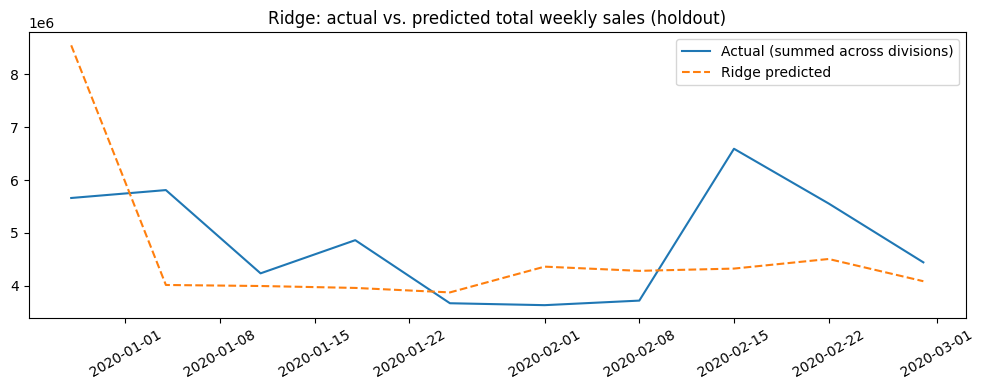

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df.loc[te_mask, "calendar_week"].unique(), df.loc[te_mask].groupby("calendar_week")[D.TARGET].sum().values, label="Actual (summed across divisions)")
pred_by_week = pd.Series(ridge_pred, index=df.loc[te_mask].index).groupby(df.loc[te_mask, "calendar_week"]).sum()
ax.plot(pred_by_week.index, pred_by_week.values, label="Ridge predicted", linestyle="--")
ax.set_title("Ridge: actual vs. predicted total weekly sales (holdout)")
ax.legend(); plt.xticks(rotation=30); plt.tight_layout()
plt.savefig("../reports/figures/01_ridge_holdout_fit.png", dpi=110)
plt.show()


## Lasso: same features, L1 penalty (does its own channel selection)

In [7]:
lasso = LassoCV(alphas=np.logspace(-4, 0, 30), cv=5, max_iter=50000)
lasso.fit(Xtr, y_log.loc[tr_mask])
lasso_pred = np.expm1(lasso.predict(Xte))
lasso_metrics = metrics(df.loc[te_mask, D.TARGET], lasso_pred)
print("Lasso best alpha:", lasso.alpha_)
print("Lasso holdout metrics:", lasso_metrics)

lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
lasso_media = lasso_coefs[[c for c in lasso_coefs.index if "_sat" in c]]
print("\nLasso media coefficients (0 = shrunk out entirely):")
print(lasso_media.sort_values(ascending=False))
print(f"\nLasso kept {(lasso_coefs != 0).sum()}/{len(lasso_coefs)} non-zero features.")


Lasso best alpha: 0.0032903445623126675
Lasso holdout metrics: {'R2': 0.8558685534632803, 'RMSE': 64035.72659258271, 'MAPE': 0.24156095454721768}

Lasso media coefficients (0 = shrunk out entirely):
spend_email_sat        2.831476
spend_facebook_sat     1.149708
spend_google_sat       0.466354
spend_affiliate_sat    0.000000
dtype: float64

Lasso kept 25/43 non-zero features.


**Key finding: Lasso zeroes out `spend_affiliate` entirely** — its holdout R² (0.856) is also noticeably better than Ridge's (0.832). With L1 regularization free to drop channels that don't earn their coefficient, Affiliate is the one channel it eliminates. This is consistent with Affiliate being **only ~1% of total media budget** ($78K of $8.3M over the training period) — there is little spend variation to identify an effect from, so different models land on very different answers for this one channel (see the ROI reconciliation in notebook 05). Google, Email, and Facebook all keep positive, broadly stable coefficients under both Ridge and Lasso.

In [8]:
summary = pd.DataFrame({"Ridge": ridge_metrics, "Lasso": lasso_metrics}).T
summary.to_csv("../reports/ridge_lasso_metrics.csv")
media_coefs.to_csv("../reports/ridge_media_coefficients.csv")
lasso_media.to_csv("../reports/lasso_media_coefficients.csv")
summary


,R2,RMSE,MAPE
Ridge,0.831523,69232.918474,0.229475
Lasso,0.855869,64035.726593,0.241561
